# Basic Self-Attention Variants - End-to-End Pipeline
**Date**: 2026-05-31  
**Objective**: Implement and compare core self-attention variants with a toy train/evaluate workflow.

## 1) Imports and Setup

In [1]:
from __future__ import annotations



import importlib.util

import math

import os

import random

from dataclasses import dataclass

from pathlib import Path



import matplotlib.pyplot as plt

import numpy as np



SEED: int = 42

random.seed(SEED)

np.random.seed(SEED)

os.environ["PYTHONHASHSEED"] = str(SEED)





def parse_use_gpu_flag(raw_value: str) -> bool:

    normalized = raw_value.strip().lower()

    return normalized not in {"0", "false", "no", "off"}





def load_runtime_env() -> None:

    env_files = [

        Path("configs/runtime.env"),

        Path("configs/runtime.env.example"),

        Path("../configs/runtime.env"),

        Path("../configs/runtime.env.example"),

    ]

    for env_file in env_files:

        if env_file.exists():

            for line in env_file.read_text(encoding="utf-8").splitlines():

                line = line.strip()

                if not line or line.startswith("#") or "=" not in line:

                    continue

                key, value = line.split("=", 1)

                os.environ.setdefault(key.strip(), value.strip().strip("\"'"))

            break





load_runtime_env()

USE_GPU = parse_use_gpu_flag(os.getenv("USE_GPU", "1"))



_torch_cuda = False

_tf_gpu = False

if importlib.util.find_spec("torch") is not None:

    import torch



    _torch_cuda = torch.cuda.is_available()

if importlib.util.find_spec("tensorflow") is not None:

    import tensorflow as tf



    tf.random.set_seed(SEED)

    _tf_gpu = bool(tf.config.list_physical_devices("GPU"))



runtime_device = "cuda" if USE_GPU and (_torch_cuda or _tf_gpu) else "cpu"

print(f"USE_GPU={int(USE_GPU)} | runtime_device={runtime_device}")


USE_GPU=1 | runtime_device=cuda


## 2) Configuration and Constants

In [2]:
@dataclass(frozen=True)
class ExperimentConfig:
    num_samples: int = 256
    seq_len: int = 24
    d_model: int = 32
    num_heads: int = 4
    num_classes: int = 2
    local_window: int = 4
    learning_rate: float = 0.2
    epochs: int = 120


CFG = ExperimentConfig()
CFG

ExperimentConfig(num_samples=256, seq_len=24, d_model=32, num_heads=4, num_classes=2, local_window=4, learning_rate=0.2, epochs=120)

## 3) Data Loading

In [3]:
def build_dataset(cfg: ExperimentConfig) -> tuple[np.ndarray, np.ndarray]:
    tokens = np.random.normal(0.0, 1.0, (cfg.num_samples, cfg.seq_len, cfg.d_model)).astype(np.float32)
    score = tokens[:, : cfg.seq_len // 2, :].mean(axis=(1, 2)) - tokens[:, cfg.seq_len // 2 :, :].mean(axis=(1, 2))
    labels = (score > 0).astype(np.int64)
    return tokens, labels


x_all, y_all = build_dataset(CFG)
split = int(0.8 * CFG.num_samples)
x_train, x_test = x_all[:split], x_all[split:]
y_train, y_test = y_all[:split], y_all[split:]
x_train.shape, y_train.shape

((204, 24, 32), (204,))

## 4) EDA

In [4]:
class_counts = np.bincount(y_all, minlength=CFG.num_classes)
print("Class counts:", class_counts.tolist())
print("Train mean/std:", float(x_train.mean()), float(x_train.std()))

Class counts: [136, 120]
Train mean/std: 0.001292505068704486 1.0007904767990112


## 5) Preprocessing and Feature Engineering

In [5]:
def project_qkv(x: np.ndarray, d_model: int) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    w_q = np.random.normal(0.0, 0.2, (d_model, d_model)).astype(np.float32)
    w_k = np.random.normal(0.0, 0.2, (d_model, d_model)).astype(np.float32)
    w_v = np.random.normal(0.0, 0.2, (d_model, d_model)).astype(np.float32)
    q = x @ w_q
    k = x @ w_k
    v = x @ w_v
    return q, k, v


q_train, k_train, v_train = project_qkv(x_train, CFG.d_model)
q_test, k_test, v_test = project_qkv(x_test, CFG.d_model)

## 6) Model Definition (Attention Variants)

In [6]:
def softmax(x: np.ndarray, axis: int = -1) -> np.ndarray:
    z = x - x.max(axis=axis, keepdims=True)
    exp_z = np.exp(z)
    return exp_z / exp_z.sum(axis=axis, keepdims=True)

def scaled_dot_product_attention(
    q: np.ndarray,
    k: np.ndarray,
    v: np.ndarray,
 ) -> tuple[np.ndarray, np.ndarray]:
    scores = (q @ np.swapaxes(k, -1, -2)) / math.sqrt(q.shape[-1])
    weights = softmax(scores, axis=-1)
    output = weights @ v
    return output, weights

def causal_attention(
    q: np.ndarray,
    k: np.ndarray,
    v: np.ndarray,
 ) -> tuple[np.ndarray, np.ndarray]:
    seq_len = q.shape[1]
    mask = np.triu(np.ones((seq_len, seq_len), dtype=bool), k=1)
    scores = (q @ np.swapaxes(k, -1, -2)) / math.sqrt(q.shape[-1])
    scores = np.where(mask[None, :, :], -1e9, scores)
    weights = softmax(scores, axis=-1)
    return weights @ v, weights

def local_window_attention(
    q: np.ndarray,
    k: np.ndarray,
    v: np.ndarray,
    window: int,
 ) -> tuple[np.ndarray, np.ndarray]:
    batch, seq_len, _ = q.shape
    scores = np.full((batch, seq_len, seq_len), -1e9, dtype=np.float32)
    raw = (q @ np.swapaxes(k, -1, -2)) / math.sqrt(q.shape[-1])
    for i in range(seq_len):
        lo = max(0, i - window)
        hi = min(seq_len, i + window + 1)
        scores[:, i, lo:hi] = raw[:, i, lo:hi]
    weights = softmax(scores, axis=-1)
    return weights @ v, weights

def multi_head_attention(
    q: np.ndarray,
    k: np.ndarray,
    v: np.ndarray,
    num_heads: int,
 ) -> tuple[np.ndarray, np.ndarray]:
    batch, seq_len, d_model = q.shape
    if d_model % num_heads != 0:
        raise ValueError(
            f"d_model ({d_model}) must be divisible by num_heads ({num_heads})."
        )
    head_dim = d_model // num_heads
    qh = q.reshape(batch, seq_len, num_heads, head_dim).transpose(0, 2, 1, 3)
    kh = k.reshape(batch, seq_len, num_heads, head_dim).transpose(0, 2, 1, 3)
    vh = v.reshape(batch, seq_len, num_heads, head_dim).transpose(0, 2, 1, 3)
    outputs: list[np.ndarray] = []
    weights_all: list[np.ndarray] = []
    for h in range(num_heads):
        out_h, w_h = scaled_dot_product_attention(qh[:, h], kh[:, h], vh[:, h])
        outputs.append(out_h)
        weights_all.append(w_h)
    out = np.stack(outputs, axis=1).transpose(0, 2, 1, 3).reshape(batch, seq_len, d_model)
    weights = np.stack(weights_all, axis=1)
    return out, weights

## 7) Training (Toy Classifier on Attention Features)

In [7]:
def pooled_features(attn_out: np.ndarray) -> np.ndarray:
    return attn_out.mean(axis=1)


attn_train, train_weights = multi_head_attention(q_train, k_train, v_train, CFG.num_heads)
attn_test, test_weights = multi_head_attention(q_test, k_test, v_test, CFG.num_heads)

x_feat_train = pooled_features(attn_train)
x_feat_test = pooled_features(attn_test)

w = np.zeros((CFG.d_model, 1), dtype=np.float32)
b = np.zeros((1,), dtype=np.float32)
y_train_f = y_train.astype(np.float32).reshape(-1, 1)

for _ in range(CFG.epochs):
    logits = x_feat_train @ w + b
    probs = 1.0 / (1.0 + np.exp(-logits))
    error = probs - y_train_f
    grad_w = (x_feat_train.T @ error) / x_feat_train.shape[0]
    grad_b = error.mean(axis=0)
    w -= CFG.learning_rate * grad_w
    b -= CFG.learning_rate * grad_b

print("Training finished.")

Training finished.


## 8) Evaluation and Metrics

In [8]:
def evaluate_binary_classifier(x_feat: np.ndarray, y_true: np.ndarray, w: np.ndarray, b: np.ndarray) -> dict[str, float]:
    logits = x_feat @ w + b
    probs = 1.0 / (1.0 + np.exp(-logits))
    preds = (probs >= 0.5).astype(np.int64).reshape(-1)
    accuracy = float((preds == y_true).mean())
    return {"accuracy": accuracy}


metrics = evaluate_binary_classifier(x_feat_test, y_test, w, b)
metrics

{'accuracy': 0.4230769230769231}

## 9) Results Visualization

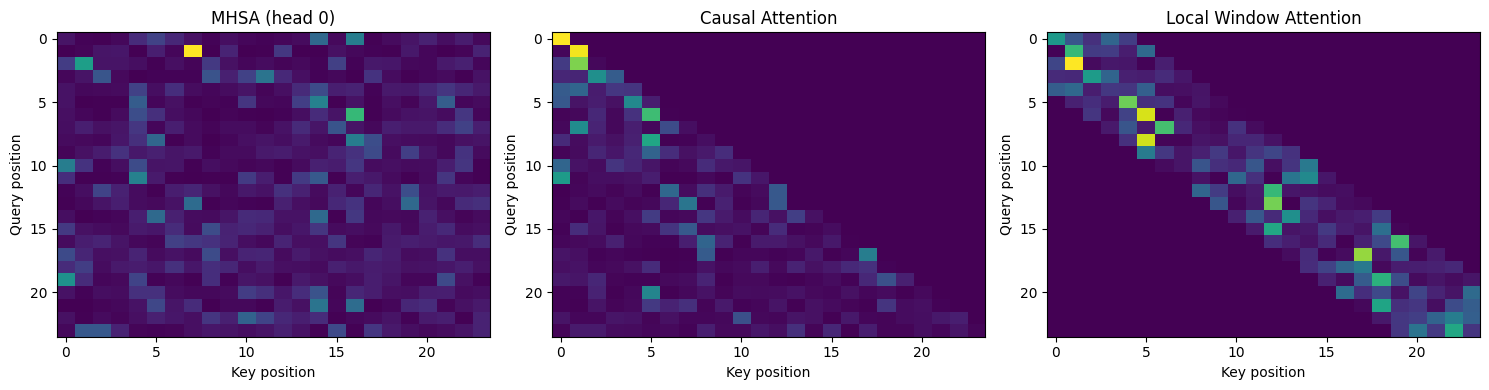

In [9]:
sample_idx = 0
head_idx = 0

causal_out, causal_w = causal_attention(q_test[:1], k_test[:1], v_test[:1])
local_out, local_w = local_window_attention(q_test[:1], k_test[:1], v_test[:1], CFG.local_window)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].imshow(test_weights[sample_idx, head_idx], aspect="auto", cmap="viridis")
axes[0].set_title("MHSA (head 0)")
axes[1].imshow(causal_w[0], aspect="auto", cmap="viridis")
axes[1].set_title("Causal Attention")
axes[2].imshow(local_w[0], aspect="auto", cmap="viridis")
axes[2].set_title("Local Window Attention")
for ax in axes:
    ax.set_xlabel("Key position")
    ax.set_ylabel("Query position")
plt.tight_layout()
plt.show()

## 10) Summary
- Implemented scaled dot-product, multi-head, causal, and local window attention in NumPy.
- Used multi-head attention features in a toy binary classifier to complete a train/evaluate flow.
- Visualized attention maps to show how masking and locality constraints change token interactions.